Gathering historical data

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

start_date = '2023-01-03'
end_date = '2026-2-23'

stock = "INTC"
index = "SPY"

# Downloading data
stock_data = yf.download(stock, start=start_date, end=end_date)
index_data = yf.download(index, start=start_date, end=end_date)

stock_data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC
Date,,,,,
2023-01-03,25.775145,26.102999,25.428006,26.083713,31308000
2023-01-04,26.691208,26.922634,26.189783,26.430852,37665200
2023-01-05,26.575497,26.787639,26.401926,26.459784,33552600
2023-01-06,27.703701,27.800129,26.401926,26.932280,31788600
2023-01-09,28.262980,28.802976,27.809770,27.809770,37493200


In [39]:
stock_log_ret = stock_data['Close'].apply(lambda x: np.log(x)).diff()
index_log_ret = index_data['Close'].apply(lambda x: np.log(x)).diff()

stock_log_ret.head()

Ticker,INTC
Date,
2023-01-03,NaN
2023-01-04,0.034924
2023-01-05,-0.004345
2023-01-06,0.041576
2023-01-09,0.019987


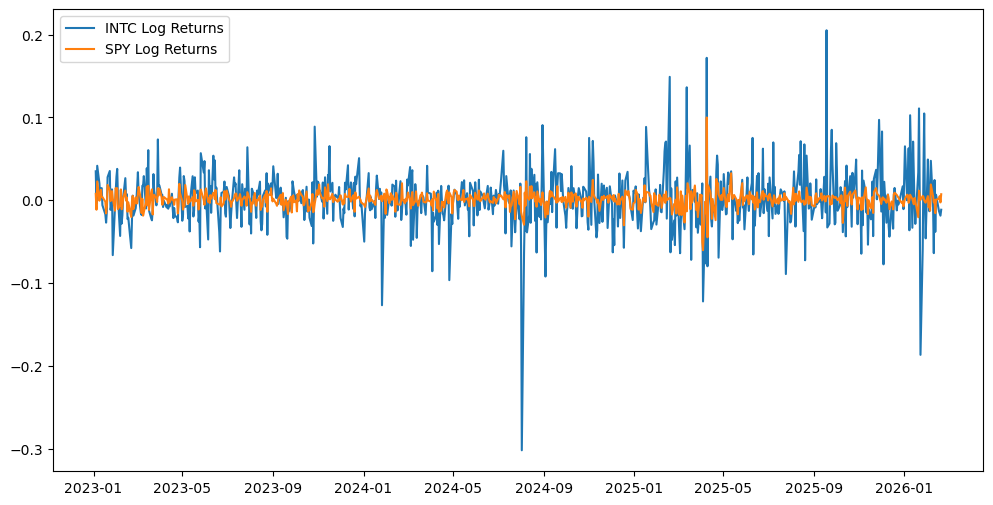

In [40]:
# plot log returns
plt.figure(figsize=(12, 6))
plt.plot(stock_log_ret, label=f'{stock} Log Returns')
plt.plot(index_log_ret, label=f'{index} Log Returns')
plt.legend()

In [38]:
rho = stock_log_ret.iloc[:, 0].corr(index_log_ret.iloc[:, 0])
print(f'Correlation between {stock} and {index}: {rho:.4f}')

Correlation between INTC and SPY: 0.4562


In [49]:
# calculate garch(1, 1) parameters
import arch
from arch import arch_model
stock_vol = arch_model(stock_log_ret.dropna(), vol='Garch', p=1, q=1, rescale=False)
index_vol = arch_model(index_log_ret.dropna(), vol='Garch', p=1, q=1, rescale=False)

stock_res = stock_vol.fit(disp='off')
index_res = index_vol.fit(disp='off')
print("-" * 30)
print(f'{stock} GARCH(1, 1) parameters:\n{stock_res.params}')
print("-" * 30)
print(f'{index} GARCH(1, 1) parameters:\n{index_res.params}')

------------------------------
INTC GARCH(1, 1) parameters:
mu         -0.000022
omega       0.000401
alpha[1]    0.380171
beta[1]     0.358789
Name: params, dtype: float64
------------------------------
SPY GARCH(1, 1) parameters:
mu          0.000945
omega       0.000009
alpha[1]    0.100000
beta[1]     0.800000
Name: params, dtype: float64


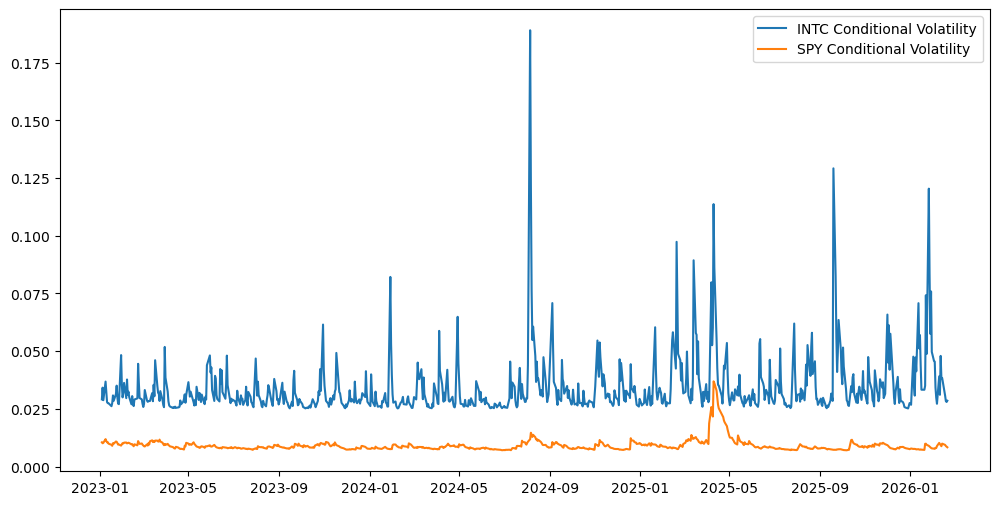

In [47]:
# plot volatility
plt.figure(figsize=(12, 6))
plt.plot(stock_res.conditional_volatility, label=f'{stock} Conditional Volatility')
plt.plot(index_res.conditional_volatility, label=f'{index} Conditional Volatility')
plt.legend()